# Setup and Data Loadin:

The first step is loading all 11 match files from Google Drive and combining them into a single master dataframe. Each match file contains a 'shots' sheet (one row per shot) and a 'points' sheet (one row per point). One important challenge: SwingVision labels players as 'host' or 'guest' in the points sheet, and this role flips depending on which player served first. To correctly assign wins and losses to my shots, I detect which role I am in each match by checking who served first in the shots sheet, then use that to create a `won_point` column. This setup cell must be run first every time the notebook is opened.



# Master Cell:

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans

# Mount Google Drive to access match files
from google.colab import drive
drive.mount('/content/drive')

# LOAD ALL MATCH FILES:
all_files = glob.glob('/content/drive/MyDrive/Data Science Final/*.xlsx')
print(f"Found {len(all_files)} match files")

all_shots = []
all_points = []

for file in all_files:
    shots_df = pd.read_excel(file, sheet_name='Shots')
    points_df = pd.read_excel(file, sheet_name='Points')

    # Swing Vision labels point winners as 'host' or 'guest', not by name
    # check who hit the first serve to figure out role
    first_server = shots_df[shots_df['Type'] == 'first_serve']['Player'].iloc[0]
    nana_role = 'host' if first_server == 'Nana Vang' else 'guest'

    # identifies which points I won
    points_df['won_point'] = (points_df['Point Winner'] == nana_role).astype(int)

    # Tag each row with which match it came from (needed when merging later)
    shots_df['match_file'] = file
    points_df['match_file'] = file

    all_shots.append(shots_df)
    all_points.append(points_df)

# Stack all matches into two master tables
master_shots = pd.concat(all_shots, ignore_index=True)
master_points = pd.concat(all_points, ignore_index=True)
print(f"Total shots loaded: {len(master_shots)}")

# FILTER TO MY SHOTS:
# Keep only shots hit by me, then attach the point outcome to each shot
my_shots = master_shots[master_shots['Player'] == 'Nana Vang'].copy()

my_shots = my_shots.merge(
    master_points[['Point', 'Game', 'Set', 'match_file', 'won_point', 'Detail', 'Serve State']],
    on=['Point', 'Game', 'Set', 'match_file'],
    how='left'
)
print(f"Nana's shots: {len(my_shots)}")
print(f"Overall point win rate: {my_shots['won_point'].mean():.1%}")

# FIX COORDINATES
# Swing Vision sometimes records shots from the opponent's perspective, flipping the y-axis
# This function normalizes everything to one direction
def fix_coordinates(df):
    df = df.copy()
    df['Bounce (x)'] = np.where(df['Bounce (y)'] > 26, -df['Bounce (x)'], df['Bounce (x)'])
    df['Bounce (y)'] = np.where(df['Bounce (y)'] > 26, 52 - df['Bounce (y)'], df['Bounce (y)'])
    return df

# HELPER: DRAW A HALF TENNIS COURT
# Used in the error clustering section
# only draw the opponent's half because that's where shots land
def draw_half_court(ax, title):
    ax.set_facecolor('#1a5276')   # dark blue background

    # The opponent's half of the court (y goes from 0 at net to ~11.89 at baseline)
    ax.add_patch(patches.Rectangle((-5.5, 0), 11, 11.89,
                 linewidth=2, edgecolor='white', facecolor='#2471a3', zorder=1))

    # Court lines
    ax.plot([-5.5, 5.5], [0, 0], color='white', linewidth=2.5, zorder=2)       # net
    ax.plot([-5.5, 5.5], [11.89, 11.89], color='white', linewidth=2, zorder=2) # baseline
    ax.plot([-5.5, -5.5], [0, 11.89], color='white', linewidth=2, zorder=2)    # left sideline
    ax.plot([5.5, 5.5], [0, 11.89], color='white', linewidth=2, zorder=2)      # right sideline
    ax.plot([-5.5, 5.5], [5.49, 5.49], color='white', linewidth=1, zorder=2)   # service line
    ax.plot([0, 0], [0, 5.49], color='white', linewidth=1, zorder=2)           # center service line

    ax.text(0, -0.6, 'NET', color='white', ha='center', fontsize=8, zorder=3)
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-1.5, 13.5)
    ax.axis('off')


Mounted at /content/drive
Found 11 match files
Total shots loaded: 4301
Nana's shots: 2117
Overall point win rate: 55.1%


### Coding Notes:

The first and most important step was figuring out how the data was actually structured.
Swing Vision exports two sheets per match: one for every individual shot and one for every
point outcome. These need to be merged together so that each shot row knows whether
the point it belonged to was won or lost.

The most involoved part of this section was the **host/guest logic**. Swing Vision does not
record point winners by name. It instead records them as "host" or "guest" depending on which
role each player was assigned when the match was created. To figure out which role I
was playing in each match, I used the first serve of the match as a reference point,
since the server is always the host. Without solving this, the entire win/loss column
would be meaningless or randomly flipped across different matches.

I also wrote two helper functions here that get reused throughout the notebook:
- `fix_coordinates()` — Swing Vision sometimes records coordinates from the opponent's
  end of the court, flipping the y-axis. This function normalizes all shots to point
  the same direction.
- `draw_half_court()` — draws a half court background used in the error section.

# Section 1: Serve Analysis

**Guiding Question:**
- Does my first serve win more points than my second serve?
- Which direction (wide, body, T) works best and does it differ between the deuce and ad side?

**Coding note:** Swing Vision records the serve bounce zone as 'ad', 'deuce', or 'center_line'. I mapped 'center_line' to 'deuce' because a serve down the T on the deuce side bounces near the center line — they represent the same tactical zone. Any bounce zones outside those three (like mislabeled or out serves) get filtered out so they don't skew the results.

In [ ]:
# SERVE DATA:

# Isolate only serve shots
serves = my_shots[my_shots['Type'].isin(['first_serve', 'second_serve'])].copy()

# Keep only serves with valid bounce zones, and combine center_line with deuce
serves_clean = serves[serves['Bounce Zone'].isin(['ad', 'deuce', 'center_line'])].copy()
serves_clean['serve_side'] = serves_clean['Bounce Zone'].replace({'center_line': 'deuce'})

# CALCULATE STATS:
# Win % by first vs second serve
serve_type = serves_clean.groupby('Type')['won_point'].agg(['mean', 'count'])
serve_type.columns = ['win_rate', 'count']
serve_type.index = ['First Serve', 'Second Serve']

# Win % by direction and court side (deuce vs ad)
serve_dir = serves_clean.groupby(['serve_side', 'Direction'])['won_point'].mean().unstack()

# Count total attempts and how many landed in for each serve type
serve_in_stats = serves.groupby('Type').agg(
    total=('Result', 'count'),
    made_in=('Result', lambda x: (x == 'In').sum())
).reset_index()

serve_in_stats['in_pct'] = serve_in_stats['made_in'] / serve_in_stats['total'] * 100
serve_in_stats['Type'] = serve_in_stats['Type'].map({
    'first_serve': 'First Serve',
    'second_serve': 'Second Serve'
})


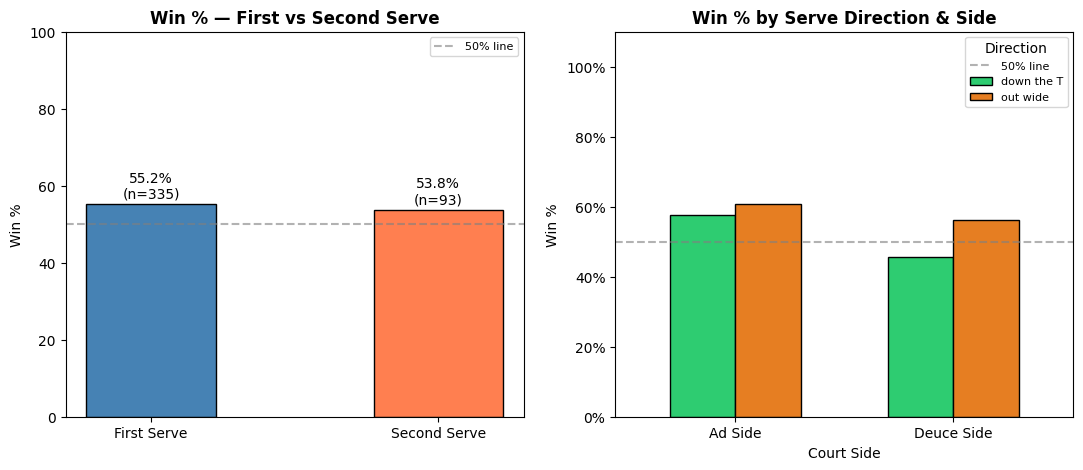

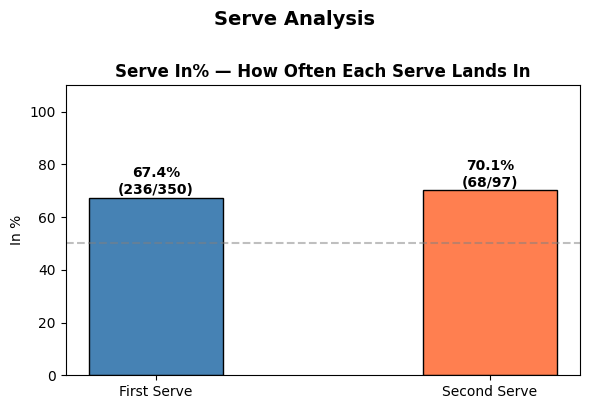

=== Win % by Serve Type ===
              win_rate  count
First Serve   0.552239    335
Second Serve  0.537634     93

=== Win % by Direction & Side ===
Direction   down the T  out wide
serve_side                      
ad                57.7      60.8
deuce             45.7      56.2


In [ ]:
# VISUALIZE:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: First vs Second Serve
colors_type = ['steelblue', 'coral']
bars = axes[0].bar(['First Serve', 'Second Serve'],
                   serve_type['win_rate'] * 100,
                   color=colors_type, edgecolor='black', width=0.45)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% line')
axes[0].set_title('Win % — First vs Second Serve', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Win %')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)
for bar, (_, row) in zip(bars, serve_type.iterrows()):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1.5,
                 f"{h:.1f}%\n(n={int(row['count'])})", ha='center', fontsize=10)

# Chart 2: Direction by Side (grouped bar)
serve_dir.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e67e22', '#9b59b6'],
               edgecolor='black', width=0.6)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50% line')
axes[1].set_title('Win % by Serve Direction & Side', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Court Side')
axes[1].set_ylabel('Win %')
axes[1].set_ylim(0, 1.1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].set_xticklabels(['Ad Side', 'Deuce Side'], rotation=0)
axes[1].legend(title='Direction', fontsize=8)

# Chart 3: First vs Second Serve Percentage

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['steelblue', 'coral']
bars = ax.bar(serve_in_stats['Type'], serve_in_stats['in_pct'],
              color=colors, edgecolor='black', width=0.4)

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Serve In% — How Often Each Serve Lands In', fontsize=12, fontweight='bold')
ax.set_ylabel('In %')
ax.set_ylim(0, 110)

for bar, (_, row) in zip(bars, serve_in_stats.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f"{h:.1f}%\n({int(row['made_in'])}/{int(row['total'])})",
            ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Serve Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print summary table
print("=== Win % by Serve Type ===")
print(serve_type.to_string())
print("\n=== Win % by Direction & Side ===")
print((serve_dir * 100).round(1).to_string())


### Coding Notes:
**Filtering serve attempts:** The shots table includes every shot type: groundstrokes,
volleys, serves, etc. The first step was isolating only first and second serves using
the `Type` column, then further filtering to only serves that landed in for the heatmap
(since faults don't have a meaningful bounce location to plot).

**Direction mapping:** Swing Vision records the serve bounce zone as 'ad', 'deuce', or
'center_line'. The center_line label needed to be mapped to 'deuce' because a serve
down the T on the deuce side bounces near the center line and they represent the same
tactical zone. Any other unexpected zone values were filtered out to avoid skewing results.


### Serve Heat Map:

For this, I want to have further my analysis by just looking at where my serves land the most. To do this, I thought it was be interesting to learn how to use a heat map.

Serves landed in: 304


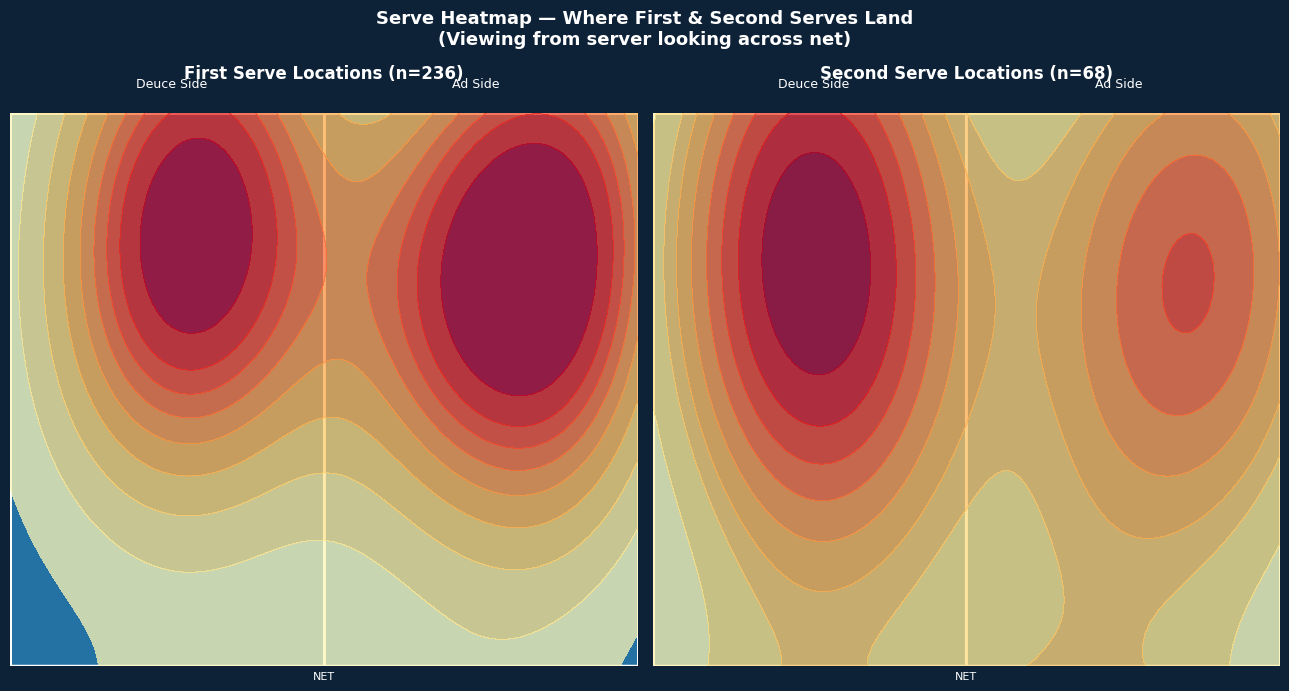

In [ ]:
import seaborn as sns

# Swing Vision has y=11.89 at the net and y=5.49 at the service line
# (opposite of what we first assumed — confirmed by where serve data clusters)
NET_Y     = 11.89
SERVICE_Y = 5.49

serves_in = serves_clean[serves_clean['Result'] == 'In'].copy()
serves_in = serves_in.dropna(subset=['Bounce (x)', 'Bounce (y)'])

print(f"Serves landed in: {len(serves_in)}")

def draw_service_boxes(ax, title):
    ax.set_facecolor('#1a5276')

    box_height = abs(NET_Y - SERVICE_Y)

    # Deuce side (left from server's view)
    ax.add_patch(patches.Rectangle((-4.115, SERVICE_Y), 4.115, box_height,
                 linewidth=2, edgecolor='white', facecolor='#2471a3', zorder=1))
    # Ad side (right from server's view)
    ax.add_patch(patches.Rectangle((0, SERVICE_Y), 4.115, box_height,
                 linewidth=2, edgecolor='white', facecolor='#2471a3', zorder=1))

    # Court lines
    ax.plot([-4.115, 4.115], [NET_Y, NET_Y], color='white', linewidth=2.5, zorder=2)        # net
    ax.plot([-4.115, 4.115], [SERVICE_Y, SERVICE_Y], color='white', linewidth=2, zorder=2)  # service line
    ax.plot([-4.115, -4.115], [SERVICE_Y, NET_Y], color='white', linewidth=2, zorder=2)     # left sideline
    ax.plot([4.115, 4.115], [SERVICE_Y, NET_Y], color='white', linewidth=2, zorder=2)       # right sideline
    ax.plot([0, 0], [SERVICE_Y, NET_Y], color='white', linewidth=1.5, zorder=2)             # center line

    ax.text(-2, SERVICE_Y - 0.3, 'Deuce Side', color='white', ha='center', fontsize=9, zorder=3)
    ax.text(2, SERVICE_Y - 0.3, 'Ad Side', color='white', ha='center', fontsize=9, zorder=3)
    ax.text(0, NET_Y + 0.15, 'NET', color='white', ha='center', fontsize=8, zorder=3)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white', pad=25)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.patch.set_facecolor('#0d2137')
fig.subplots_adjust(top=0.85)   # keeps title from overlapping labels

for ax, (serve_label, serve_type) in zip(axes, [('First Serve', 'first_serve'), ('Second Serve', 'second_serve')]):
    subset = serves_in[serves_in['Type'] == serve_type]

    draw_service_boxes(ax, f'{serve_label} Locations (n={len(subset)})')

    if len(subset) >= 5:
        sns.kdeplot(
            x=subset['Bounce (x)'],
            y=subset['Bounce (y)'],
            ax=ax,
            fill=True,
            cmap='YlOrRd',
            alpha=0.75,
            thresh=0.05,
            levels=10,
            zorder=3
        )

    ax.set_xlim(-4.115, 4.115)
    ax.set_ylim(SERVICE_Y, NET_Y)
    ax.invert_yaxis()   # net at top, service line at bottom

plt.suptitle('Serve Heatmap — Where First & Second Serves Land\n(Viewing from server looking across net)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

### Coding Notes:
**Heatmap coordinate system:** The most involved part of this section was getting the
serve heatmap to display correctly. Swing Vision uses a coordinate system where y=11.89
is the net and y=5.49 is the service line which the opposite of what I mistakenly assume from
reading the numbers. Figuring this out required printing the raw coordinate ranges and
cross-referencing them with known court dimensions (net to service line = 6.4m, service
line to baseline = 5.49m). The heatmap also required clipping the axes to the service
box boundaries using `ax.set_xlim()` and `ax.set_ylim()`, otherwise the KDE smoothing
would bleed visually outside the lines even though all the data points were valid in-serves.

**Learning New Heatmap Technique:**
This was easily the most ambitious part of my project that took up most of the time. I used a wide range of resources such as plotly website, Datacamp, Gemini, and lots of guess and check to really get an understanding of coding   The heatmap uses `seaborn`'s `kdeplot` function, which was a new tool for this project.
KDE stands for Kernel Density Estimation which takes a set of x/y coordinates and smooths
them into a continuous heat gradient rather than plotting individual dots. The result is
easier to read than a scatter plot when there are hundreds of overlapping points.

Layering the KDE on top of a custom-drawn court background required understanding
`zorder`, which controls the draw order of matplotlib elements. The court lines needed
a higher zorder than the heatmap fill so they stayed visible on top of the color gradient.

One important limitation: the heatmap only shows serves that landed in. Faults are
excluded because their bounce coordinates are not meaningful — a serve that clips the
net or lands wide doesn't have a useful bounce location inside the service box.
This means the heatmap shows *where good serves go*, not the full picture of all attempts.


### Serve Results/Analysis:


The direction breakdown was the most surprising finding. Out wide is the highest win %
direction on both the ad and deuce side, but the heatmap shows most serves are actually
landing toward the middle of the box — not wide. This is a direct contradiction between
what works and what is actually happening in matches, and it is one of the clearest
actionable findings in the project.

The down the T serve on the deuce side came in below 50% win rate, meaning it loses
more points than it wins. A likely explanation is that it is a predictable direction
on that side and opponents are reading it early.

First serve in% at 67.4% is functional but leaves room to improve. The second serve
going in at a slightly higher rate (70.1%) reflects the added spin and reduced pace
used to ensure it lands — a normal trade-off between consistency and aggression.


# Section 2: Win % at Baseline vs. Net
**Guiding Question:**

How effecitive am I at the **baseline** vs. **net**?
 Everything else is counted as baseline. This is a simplification as it classifies the shot type, not my exact position on the court.

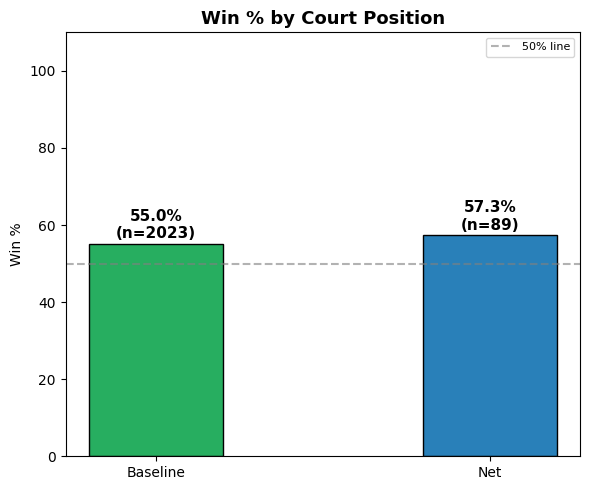

=== Win % by Court Position ===
position  win_rate  total_points
Baseline  0.550173          2023
     Net  0.573034            89


In [ ]:
# LABEL EACH SHOT BY COURT POSITION

# Net shots = volleys and overheads. All other shots = baseline.
my_shots['position'] = my_shots['Stroke'].apply(
    lambda x: 'Net' if x in ['FH Volley', 'BH Volley', 'Overhead'] else 'Baseline'
)

# CALCULATE WIN % BY POSITION
position_stats = my_shots.groupby('position')['won_point'].agg(
    win_rate='mean',
    total_points='count'
).reset_index()

# VISUALIZE
fig, ax = plt.subplots(figsize=(6, 5))

colors = ['#27ae60', '#2980b9']
bars = ax.bar(position_stats['position'], position_stats['win_rate'] * 100,
              color=colors, edgecolor='black', width=0.4)

ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% line')
ax.set_title('Win % by Court Position', fontsize=13, fontweight='bold')
ax.set_ylabel('Win %')
ax.set_ylim(0, 110)
ax.legend(fontsize=8)

# Label each bar with win % and sample size
for bar, (_, row) in zip(bars, position_stats.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f"{h:.1f}%\n(n={int(row['total_points'])})",
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== Win % by Court Position ===")
print(position_stats.to_string(index=False))


### Coding Notes:
The main coding challenge here was defining "net" from shot data alone, since Swing
Vision does not directly record court position. The solution was to use stroke type
as a proxy. For the most part volleys and overheads only happen at the net, so any shot labeled
`FH Volley`, `BH Volley`, or `Overhead` was classified as a net point. Everything
else was counted as baseline.

The sample size (n=) label on each bar was added intentionally because a small number of
net points could make the win % look misleadingly high or low, so showing the count
alongside the percentage gives a more honest picture.

### Positioning Results/Interpretations:

Because my **net win %** is higher than my baseline win %, it suggests net approaches are more effective. While the sample size at net is significantly smaller than the baseline data, I still believe its large enough on it's own to give a reasonable result. I also added the 50% dotted gray line on the chart as to represent the minimum I would like to have in my game. As if any of them are below that 50% mark, it would suggest an ineffective strategy.



## Section 3: Rally Length Analysis


**Guiding Question:**

What types of points am I the most successful at in terms of length?
How am I losing shorter points?

- **1–4 shots** = short/serve-dominated points
- **5–9 shots** = medium rallies
- **10–14 shots** = longer exchanges
- **15+ shots** = extended baseline battles



/tmp/ipykernel_3950/4132552145.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(short_detail.index, rotation=15, ha='right', fontsize=8)


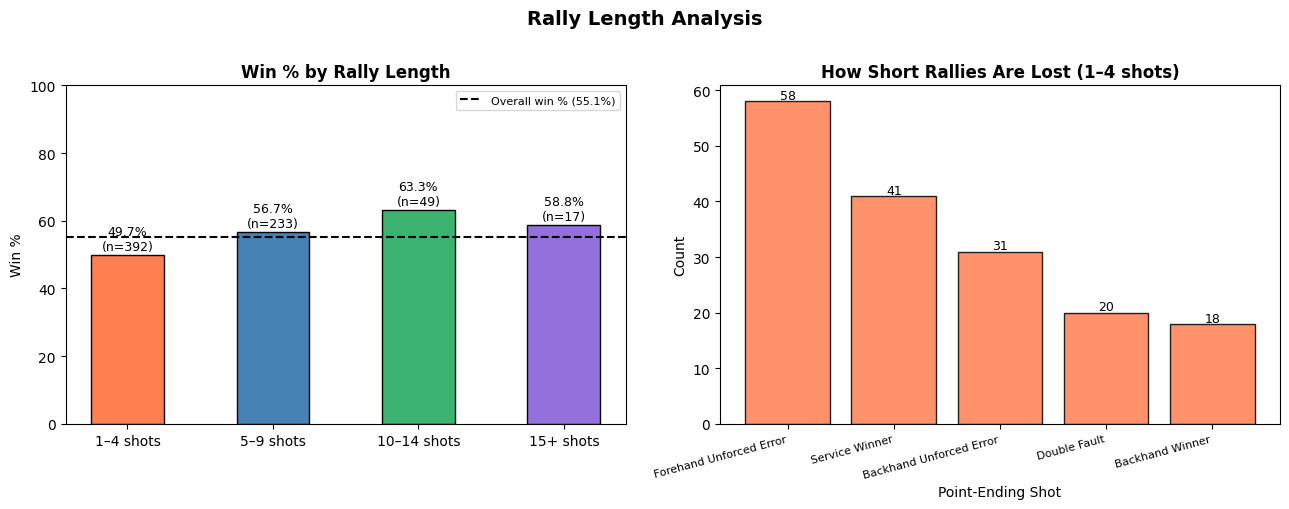

=== Win % by Rally Length ===
  1–4 shots: 49.7%  (n=392)
  5–9 shots: 56.7%  (n=233)
  10–14 shots: 63.3%  (n=49)
  15+ shots: 58.8%  (n=17)


In [ ]:
# BUILD RALLY LENGTH TABLE

# Count the total shots in each point (max shot number = rally length)
# Also grab whether I won the point
rally_lengths = my_shots.groupby(['Point', 'Game', 'Set', 'match_file']).agg(
    rally_length=('Shot', 'max'),
    won_point=('won_point', 'first')
).reset_index()

# Sort each point into a rally-length bucket
bins   = [0, 4, 9, 14, 100]
labels = ['1–4 shots', '5–9 shots', '10–14 shots', '15+ shots']
rally_lengths['rally_group'] = pd.cut(rally_lengths['rally_length'],
                                       bins=bins, labels=labels)

# Win % and count per bucket
rally_stats = rally_lengths.groupby('rally_group', observed=True).agg(
    count=('won_point', 'count'),
    win_rate=('won_point', 'mean')
).reset_index()

# FIND HOW SHORT RALLIES ARE LOST
# Get the last shot of each point (the shot that ended the point)
last_shots = my_shots.sort_values('Shot').groupby(
    ['Point', 'Game', 'Set', 'match_file']
).last().reset_index()

# Attach rally length info to the last-shot table
rally_with_detail = rally_lengths.merge(
    last_shots[['Point', 'Game', 'Set', 'match_file', 'Detail']],
    on=['Point', 'Game', 'Set', 'match_file'], how='left'
)

# Filter to: short rallies that I lost
short_losses = rally_with_detail[
    (rally_with_detail['rally_length'] <= 4) &
    (rally_with_detail['won_point'] == 0)
]
short_detail = short_losses['Detail'].value_counts().head(5)

# Overall win rate (for reference line)
overall_win_pct = my_shots['won_point'].mean() * 100

# VISUALIZE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['coral', 'steelblue', 'mediumseagreen', 'mediumpurple']

# Chart 1: Win % by rally group
bars = axes[0].bar(rally_stats['rally_group'], rally_stats['win_rate'] * 100,
                   color=colors, edgecolor='black', width=0.5)
axes[0].axhline(overall_win_pct, color='black', linewidth=1.5,
                linestyle='--', label=f'Overall win % ({overall_win_pct:.1f}%)')
axes[0].set_title('Win % by Rally Length', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Win %')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)
for bar, (_, row) in zip(bars, rally_stats.iterrows()):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1.5,
                 f"{h:.1f}%\n(n={int(row['count'])})", ha='center', fontsize=9)

# Chart 2: How short rallies are lost
axes[1].bar(short_detail.index, short_detail.values,
            color='coral', edgecolor='black', alpha=0.85)
axes[1].set_title('How Short Rallies Are Lost (1–4 shots)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Point-Ending Shot')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(short_detail.index, rotation=15, ha='right', fontsize=8)
for i, v in enumerate(short_detail.values):
    axes[1].text(i, v + 0.4, str(v), ha='center', fontsize=9)

plt.suptitle('Rally Length Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("=== Win % by Rally Length ===")
for _, row in rally_stats.iterrows():
    print(f"  {row['rally_group']}: {row['win_rate']:.1%}  (n={int(row['count'])})")


### Coding Notes:

This section introduced two pandas tools worth explaining:

**`pd.cut()`**: this function takes a continuous variable (number of shots in a rally)
and sorts each value into labeled buckets. Instead of analyzing every possible rally
length individually, `pd.cut()` groups them into ranges like "1–4 shots" and "5–9 shots"
which are easier to compare and more meaningful tactically.

**Groupby + aggregation**: after bucketing rallies, `groupby()` with `.agg()` was used
to calculate both the win rate and the count for each bucket in one step. Combining
multiple aggregation functions in a single `.agg()` call (rather than running separate
calculations) keeps the code cleaner and avoids creating unnecessary intermediate variables.

The second chart required identifying the last shot of
each point. This was done by sorting shots by shot number and taking the final row per
point using `.groupby().last()`. The `Detail` column on that last shot describes how
the point ended, which is where categories like "double fault" or "winner" come from.

### Rally Length Results/Interpretation:

The dashed line represents the overall win rate across all points, which acts as a
baseline for comparison. Any rally bucket above the line is a length where performance
is above average; any bucket below is a relative weakness.

The second chart breaks down short rally losses specifically, which is useful because
1–4 shot points are heavily influenced by the serve. A high number of double faults
or return winners in short rallies points directly to serve issues rather than baseline
consistency problems.


## Section 4: Drop Shot Analysis

**Guiding Question:**
What shot gives me the most opportunity to hit a drop shot?




In [ ]:
# ── IDENTIFY DROP SHOTS ───────────────────────────────────────────────
# Definition: short bounce + slice spin + under 35 mph + not a serve
drop_shots = my_shots[
    (my_shots['Bounce Depth'] == 'short') &
    (my_shots['Spin'] == 'Slice') &
    (my_shots['Speed (MPH)'] < 35) &
    (~my_shots['Type'].isin(['first_serve', 'second_serve']))
].copy()

print(f"Drop shots identified: {len(drop_shots)}")
print(f"Drop shot win rate: {drop_shots['won_point'].mean():.1%}")

# ── FIND THE SETUP SHOT ───────────────────────────────────────────────
# For each drop shot, look 2 shots back (or 1 if 2 isn't available)
# to find what I hit right before the drop shot
setup_shots = []

for idx in drop_shots.index:
    row = my_shots.loc[idx]
    shot_num  = row['Shot']
    point     = row['Point']
    game      = row['Game']
    set_      = row['Set']
    match     = row['match_file']

    # Try to get the shot 2 before
    prev = my_shots[
        (my_shots['Point'] == point) & (my_shots['Game'] == game) &
        (my_shots['Set'] == set_) & (my_shots['match_file'] == match) &
        (my_shots['Player'] == 'Nana Vang') & (my_shots['Shot'] == shot_num - 2)
    ]

    # Fall back to 1 shot before if 2 isn't there
    if len(prev) == 0:
        prev = my_shots[
            (my_shots['Point'] == point) & (my_shots['Game'] == game) &
            (my_shots['Set'] == set_) & (my_shots['match_file'] == match) &
            (my_shots['Player'] == 'Nana Vang') & (my_shots['Shot'] == shot_num - 1)
        ]

    if len(prev) > 0:
        setup = prev.iloc[0].to_dict()
        setup['drop_shot_won'] = row['won_point']   # did the drop shot point win?
        setup_shots.append(setup)

setup_df = pd.DataFrame(setup_shots)
print(f"Setup shots found: {len(setup_df)} of {len(drop_shots)}")

# BUILD SETUP COMBO LABELS
# Label each setup shot as "Stroke | Direction | Depth"
setup_df['shot_label'] = (setup_df['Stroke'] + ' | ' +
                          setup_df['Direction'] + ' | ' +
                          setup_df['Bounce Depth'])

# Calculate win rate for each setup combo (min 3 occurrences to count)
shot_combos = setup_df.groupby('shot_label')['drop_shot_won'].agg(['mean', 'count'])
shot_combos.columns = ['win_rate', 'count']
shot_combos = shot_combos[shot_combos['count'] >= 3].sort_values('win_rate', ascending=False)


Drop shots identified: 90
Drop shot win rate: 48.3%
Setup shots found: 78 of 90


### Coding Notes:

Drop shots were the hardest shot type to identify from the data because Swing Vision
has no "drop shot" label. The definition used here combines three conditions: bounce
depth is short, spin is slice, and speed is under 35 mph. Each condition alone would
catch too many false positives (a regular short slice or a slow rally ball) but
the combination together reliably isolates intentional drop shots.

The setup shot analysis required building a custom loop rather than using a standard
pandas operation. For each drop shot, the loop looks backward two shots (or one if
two isn't available) within the same point to find the shot Nana hit right before
the drop shot. This required filtering by point, game, set, and match file
simultaneously to make sure shots from different points were never mixed together.

The minimum count filter (`count >= 3`) was added to avoid showing setup combos
that only appeared once or twice as a single data point is not enough to draw a
reliable conclusion about whether a setup is actually effective.

### Visualization:

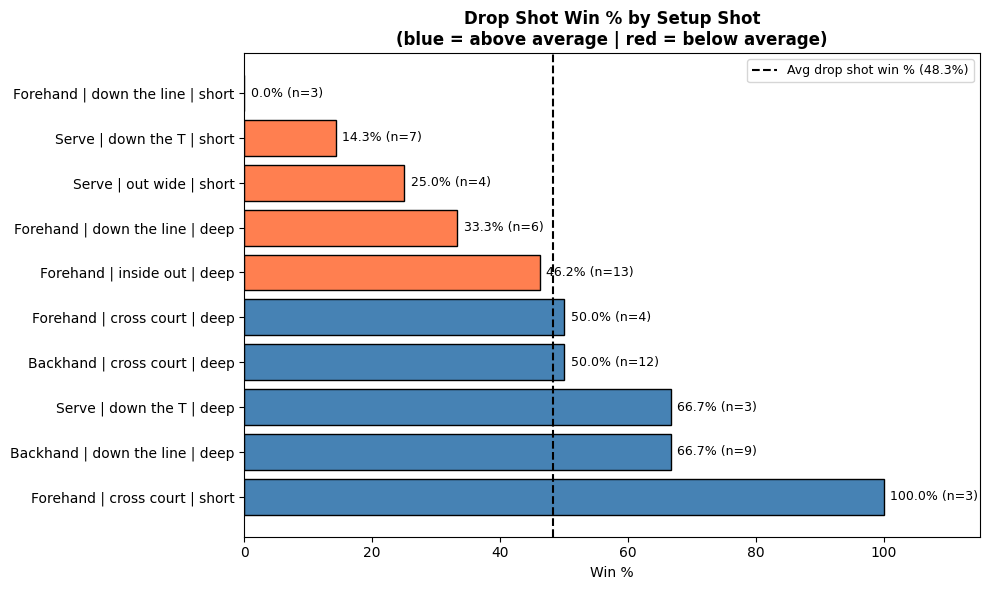

=== Drop Shot Summary ===
                                  win_rate  count
shot_label                                       
Forehand | cross court | short    1.000000      3
Backhand | down the line | deep   0.666667      9
Serve | down the T | deep         0.666667      3
Backhand | cross court | deep     0.500000     12
Forehand | cross court | deep     0.500000      4
Forehand | inside out | deep      0.461538     13
Forehand | down the line | deep   0.333333      6
Serve | out wide | short          0.250000      4
Serve | down the T | short        0.142857      7
Forehand | down the line | short  0.000000      3


In [ ]:
# ── VISUALIZE DROP SHOT SETUP ─────────────────────────────────────────
overall_ds_win = drop_shots['won_point'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Color bars blue if above average win rate, red if below
bar_colors = ['steelblue' if w >= overall_ds_win/100 else 'coral'
              for w in shot_combos['win_rate']]

ax.barh(shot_combos.index, shot_combos['win_rate'] * 100,
        color=bar_colors, edgecolor='black')
ax.axvline(overall_ds_win, color='black', linewidth=1.5,
           linestyle='--', label=f'Avg drop shot win % ({overall_ds_win:.1f}%)')

ax.set_xlabel('Win %')
ax.set_title('Drop Shot Win % by Setup Shot\n(blue = above average | red = below average)',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, 115)
ax.legend(fontsize=9)

# Label each bar with win % and sample size
for i, (_, row) in enumerate(shot_combos.iterrows()):
    ax.text(row['win_rate'] * 100 + 1, i,
            f"{row['win_rate']:.1%} (n={int(row['count'])})",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Drop Shot Summary ===")
print(shot_combos.to_string())


### Drop Shot Results/Interpretation:


The horizontal bar chart uses color to separate above-average setups (blue) from
below-average ones (red) relative to the overall drop shot win rate. The most useful
setups are the ones that appear frequently *and* win at a high rate.

Below-average setups are worth examining tactically as they likely represent drop shots
hit from defensive positions or when the opponent is already close to the net, which
reduces the element of surprise that makes the drop shot effective.

# Section 5 — Backhand Slice Analysis

**Guiding Question:** What is my most effective backhand slice?

This section looks at my backhand slice in detail. By breaking my slice  into four tactical types based on depth and direction and tracking what my opponent does after each type, I can see which slice yields the best output most consistently.



In [ ]:
# IDENTIFY BACKHAND SLICES (EXCLUDING DROP SHOTS)
# We want real slices — speed >= 35 mph separates them from drop shots
bh_slices_clean = my_shots[
    (my_shots['Stroke'] == 'Backhand') &
    (my_shots['Spin'] == 'Slice') &
    (my_shots['Speed (MPH)'] >= 35) &
    (~my_shots['Type'].isin(['first_serve', 'second_serve']))
].copy()

# CLASSIFY INTO 4 TACTICAL TYPES
# Deep Cross, Deep Line, Short Cross, Short Line
def classify_slice(row):
    depth     = row['Bounce Depth']
    direction = row['Direction']
    if depth == 'out':
        return None
    depth_label = 'Deep' if depth == 'deep' else 'Short'
    if direction in ['cross court', 'inside in']:
        dir_label = 'Cross'
    elif direction in ['down the line', 'inside out']:
        dir_label = 'Line'
    else:
        return None
    return f"{depth_label} {dir_label}"

bh_slices_clean['slice_type'] = bh_slices_clean.apply(classify_slice, axis=1)
bh_slices_clean = bh_slices_clean[bh_slices_clean['slice_type'].notna()].copy()

print(f"Backhand slices identified: {len(bh_slices_clean)}")
print(bh_slices_clean['slice_type'].value_counts())

# BUILD 3-SHOT SEQUENCES
# For each slice: look at what the opponent did next, then what Nana did after that
all_sequences = []

for idx in bh_slices_clean.index:
    row      = my_shots.loc[idx]
    shot_num = row['Shot']
    point    = row['Point']
    game     = row['Game']
    set_     = row['Set']
    match    = row['match_file']

    # All shots from this point (both players), in order
    point_all = master_shots[
        (master_shots['Point'] == point) & (master_shots['Game'] == game) &
        (master_shots['Set'] == set_) & (master_shots['match_file'] == match)
    ].sort_values('Shot')

    # Opponent's very next shot
    opp_next = point_all[
        (point_all['Player'] != 'Nana Vang') & (point_all['Shot'] == shot_num + 1)
    ]

    # My shot after that
    nana_next = point_all[
        (point_all['Player'] == 'Nana Vang') & (point_all['Shot'] == shot_num + 2)
    ]

    # Classify what the opponent did with the slice
    if len(opp_next) == 0:
        last = point_all.iloc[-1]
        if last['Result'] == 'In' and last['Player'] == 'Nana Vang':
            opp_response = 'Slice Winner'
        elif last['Player'] == 'Nana Vang' and last['Result'] in ['Net', 'Out']:
            opp_response = 'Slice Error'
        else:
            opp_response = 'Other'
    elif opp_next.iloc[0]['Result'] in ['Net', 'Out']:
        opp_response = 'Opponent Error'
    elif opp_next.iloc[0]['Bounce Depth'] == 'short':
        opp_response = 'Short Ball (Attackable)'
    elif opp_next.iloc[0]['Bounce Depth'] == 'deep':
        opp_response = 'Deep Ball (Defensive)'
    else:
        opp_response = 'Other'

    all_sequences.append({
        # FIX: slice_type comes from bh_slices_clean, not row —
        # because my_shots doesn't have this column
        'slice_type':       bh_slices_clean.loc[idx, 'slice_type'],
        'won_point':        row['won_point'],
        'opp_response':     opp_response,
        'nana_next_stroke': nana_next.iloc[0]['Stroke'] if len(nana_next) > 0 else 'none',
    })

seq_df = pd.DataFrame(all_sequences)

print("\n=== Win Rate by Slice Type ===")
print(seq_df.groupby('slice_type')['won_point'].agg(['mean', 'count']).round(3))
print("\n=== Win Rate by Opponent Response ===")
print(seq_df.groupby('opp_response')['won_point'].agg(['mean', 'count']).round(3))

Backhand slices identified: 164
slice_type
Deep Line      59
Deep Cross     59
Short Cross    26
Short Line     20
Name: count, dtype: int64

=== Win Rate by Slice Type ===
              mean  count
slice_type               
Deep Cross   0.559     59
Deep Line    0.593     59
Short Cross  0.462     26
Short Line   0.750     20

=== Win Rate by Opponent Response ===
                          mean  count
opp_response                         
Deep Ball (Defensive)    0.579     76
Opponent Error           0.643     28
Other                    0.000      2
Short Ball (Attackable)  0.513     39
Slice Error              0.583     12
Slice Winner             0.857      7


### Coding Notes:
The slice section was the most technically complex in the notebook. The core challenge
was building a three-shot sequence: the slice itself, the opponent's response, and
Nana's next shot. This required accessing both players' shot records within the same
point, which meant working from `master_shots` (all shots, both players) rather than
`my_shots`.

Classifying the opponent's response into categories like "Short Ball (Attackable)" and
"Deep Ball (Defensive)" required a series of conditional checks. The order of those
checks matters. For example, if the opponent's next shot has no entry at all, that usually means
the point ended on my slice (either a winner or an error), so that case gets
handled first before checking bounce depth.

One bug that came up during development: the `slice_type` column was added to
`bh_slices_clean` but the loop was pulling rows from `my_shots`, which never had that
column. The fix was to look up `slice_type` directly from `bh_slices_clean` using
the index (`bh_slices_clean.loc[idx, 'slice_type']`) rather than from the row variable.

/tmp/ipykernel_3950/3305943731.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(slice_win.index, rotation=10, ha='right')
/tmp/ipykernel_3950/3305943731.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(response_pct.index, rotation=10, ha='right')


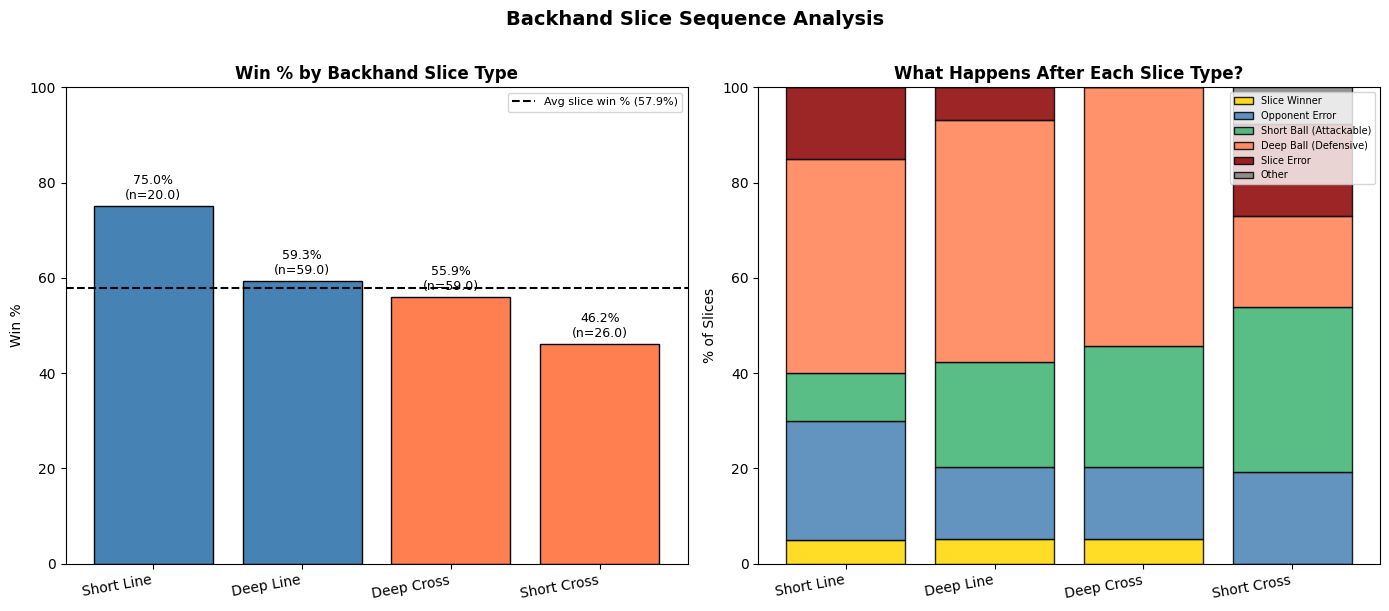

In [ ]:
# ── VISUALIZE SLICE ANALYSIS ─────────────────────────────────────────
overall_slice_win = seq_df['won_point'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Win % by slice type
slice_win = seq_df.groupby('slice_type')['won_point'].agg(['mean', 'count'])
slice_win = slice_win.sort_values('mean', ascending=False)

bar_colors = ['steelblue' if w >= overall_slice_win/100 else 'coral'
              for w in slice_win['mean']]

axes[0].bar(slice_win.index, slice_win['mean'] * 100,
            color=bar_colors, edgecolor='black')
axes[0].axhline(overall_slice_win, color='black', linewidth=1.5,
                linestyle='--', label=f'Avg slice win % ({overall_slice_win:.1f}%)')
axes[0].set_title('Win % by Backhand Slice Type', fontweight='bold')
axes[0].set_ylabel('Win %')
axes[0].set_ylim(0, 100)
axes[0].set_xticklabels(slice_win.index, rotation=10, ha='right')
axes[0].legend(fontsize=8)
for i, (_, row) in enumerate(slice_win.iterrows()):
    axes[0].text(i, row['mean'] * 100 + 1.5,
                 f"{row['mean']:.1%}\n(n={row['count']})",
                 ha='center', fontsize=9)

# Chart 2: Stacked bar — what happens after each slice type
slice_order = slice_win.index.tolist()
response_counts = seq_df.groupby(['slice_type', 'opp_response']).size().unstack(fill_value=0)
response_counts = response_counts.reindex(slice_order)
response_pct = response_counts.div(response_counts.sum(axis=1), axis=0) * 100

response_colors = {
    'Slice Winner':          'gold',
    'Opponent Error':        'steelblue',
    'Short Ball (Attackable)': 'mediumseagreen',
    'Deep Ball (Defensive)': 'coral',
    'Slice Error':           'darkred',
    'Other':                 'gray'
}

bottom = np.zeros(len(response_pct))
for response, color in response_colors.items():
    if response in response_pct.columns:
        axes[1].bar(response_pct.index, response_pct[response],
                    bottom=bottom, label=response,
                    color=color, edgecolor='black', alpha=0.85)
        bottom += response_pct[response].values

axes[1].set_title('What Happens After Each Slice Type?', fontweight='bold')
axes[1].set_ylabel('% of Slices')
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(response_pct.index, rotation=10, ha='right')
axes[1].legend(fontsize=7, loc='upper right')

plt.suptitle('Backhand Slice Sequence Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


The two charts work together. The bar chart shows which slice type wins the most points,
and the stacked bar shows *why*, what the slice is actually forcing the opponent to do.

A slice that generates a lot of "Short Ball (Attackable)" responses is doing its job.
It is pulling the opponent forward and creating an opportunity to attack. A slice that
mostly generates "Deep Ball (Defensive)" responses means the opponent is absorbing it
comfortably and neutralizing the tactic. That distinction is more useful than win rate
alone because it shows the mechanism, not just the outcome.

# Final Reflection

### Coding Process & Challenges

This project involved working with real, imperfect sports data which turned out to be one of the most valuable learning experiences.

**The biggest challenge** was parsing through all the swingvision data to see what categories I need to create and how Swingvision used premade ones. For example there's no "drop shot" column and the shot coordinates sometimes flip direction depending on which end of the court was recorded. A lot of the early work was just figuring out how the data is structured before doing any actual analysis. Much of this was towards the beginning of the project, however the most painstaking part of building some of the visualizations, specifically the heatmap. While I'm glad I continued with the idea, to figure out the coordinates and make them portional to my "service boxes" was incredibly hard. Honestly, every visualization was quite challenging however the repetition I gathered with bar charts definitely sped up in the end.

**Things that were harder than expected:**
- The host/guest role logic for determining point winners — it required understanding how Swing Vision assigns match roles
- Building multi-shot sequences for drop shots and slices, which meant cross-referencing rows across both the shots and points tables, and across both players
- Normalizing coordinates so that all shots pointed in the same direction (the `fix_coordinates()` function)
- Building Visualizations

**Things that were easier than expected:**
- Once the master data tables were built, groupby operations in pandas were very readable and didn't require much code
- K-Means was surprisingly straightforward to apply — the sklearn library handles most of the math, and the main decision is just picking *k* (number of clusters)
- Already mentioned before, once I got the hang of most of the bar charts, much of it was templated

---

### Understanding the Results

The most useful outputs from this project aren't the individual stats but the comparisons:
- First vs second serve win % shows whether the second serve is being attacked
- Baseline vs net win % shows if net approaches are actually worth taking
- Rally length win % shows where in a point the player is most/least comfortable
- Drop shot and slice setups show *tactical context*, not just outcomes

**What makes this analysis valuable** is that it's all based on real match data from real competitive points. Most tennis practice feedback is qualitative ("your forehand looked off today"). This project makes it quantitative: *your forehand errors cluster in zone 2 (wide), and your backhand errors cluster near the net.* Those are two different problems requiring two different solutions.

---

### If I Were to Extend This Project

A few directions this could go further:
- **Opponent-specific analysis:** Do error patterns change against different opponents?
- **Score-state analysis:** Does performance drop on break points or in deciding sets?
- **Time/fatigue analysis:** Does win % decline in the 3rd set vs the 1st?
- **Model building:** Could a simple classifier predict whether a shot will be a winner or error based on speed, direction, and depth?

This project was a first step and I want to continue to refine this project in hopes to actually be able to implement other peoples matches in here so they can also look at their matches analytically.
